In [2]:
!pip install gymnasium -q

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("GPU available:", torch.cuda.is_available())

env = gym.make('CartPole-v1')
print("CartPole state space:", env.observation_space)
print("CartPole action space:", env.action_space)

GPU available: True
CartPole state space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
CartPole action space: Discrete(2)


In [5]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return np.array(state), action, reward, np.array(next_state), done
    def __len__(self):
        return len(self.buffer)

def train_dqn(env_name, state_dim, action_dim, episodes=300, discrete_state=False, n_states=None):
    env = gym.make(env_name)
    policy_net = DQN(state_dim, action_dim).to(device)
    target_net = DQN(state_dim, action_dim).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
    buffer = ReplayBuffer()

    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    episode_rewards = []

    def encode_state(s):
        if discrete_state:
            one_hot = np.zeros(n_states, dtype=np.float32)
            one_hot[s] = 1.0
            return one_hot
        return np.array(s, dtype=np.float32)

    for episode in range(episodes):
        state, _ = env.reset()
        state = encode_state(state)
        total_reward = 0
        done = False

        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = policy_net(state_t).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_enc = encode_state(next_state)
            buffer.push(state, action, reward, next_state_enc, done)
            state = next_state_enc
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards, next_states, dones = buffer.sample(batch_size)
                states = torch.FloatTensor(states).to(device)
                actions = torch.LongTensor(actions).to(device)
                rewards = torch.FloatTensor(rewards).to(device)
                next_states = torch.FloatTensor(next_states).to(device)
                dones = torch.FloatTensor(dones).to(device)

                q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(next_states).max(1)[0]
                    target_q = rewards + gamma * next_q * (1 - dones)
                loss = nn.functional.mse_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

        if episode % 20 == 0:
            target_net.load_state_dict(policy_net.state_dict())
            print(f"Episode {episode}, Reward: {total_reward:.1f}, Epsilon: {epsilon:.3f}")

    return policy_net, episode_rewards

In [6]:
policy_net_cartpole, rewards_cartpole = train_dqn('CartPole-v1', state_dim=4, action_dim=2, episodes=300)

Episode 0, Reward: 29.0, Epsilon: 0.995
Episode 20, Reward: 23.0, Epsilon: 0.900
Episode 40, Reward: 13.0, Epsilon: 0.814
Episode 60, Reward: 20.0, Epsilon: 0.737
Episode 80, Reward: 23.0, Epsilon: 0.666
Episode 100, Reward: 23.0, Epsilon: 0.603
Episode 120, Reward: 49.0, Epsilon: 0.545
Episode 140, Reward: 30.0, Epsilon: 0.493
Episode 160, Reward: 118.0, Epsilon: 0.446
Episode 180, Reward: 131.0, Epsilon: 0.404
Episode 200, Reward: 68.0, Epsilon: 0.365
Episode 220, Reward: 99.0, Epsilon: 0.330
Episode 240, Reward: 26.0, Epsilon: 0.299
Episode 260, Reward: 93.0, Epsilon: 0.270
Episode 280, Reward: 13.0, Epsilon: 0.245


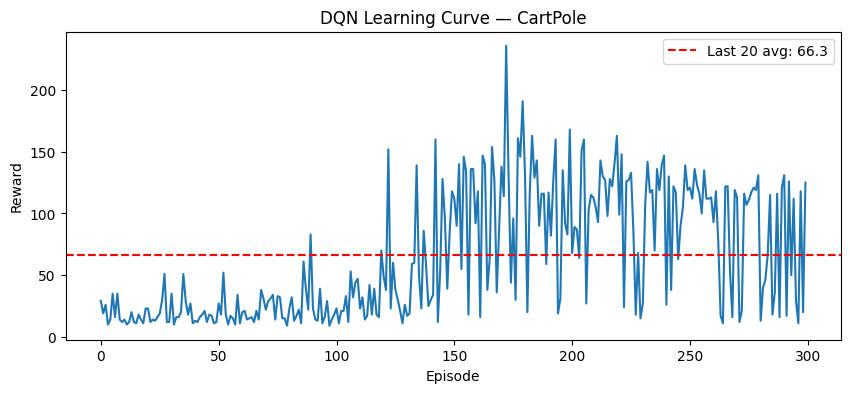

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rewards_cartpole)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN Learning Curve — CartPole')
plt.axhline(y=np.mean(rewards_cartpole[-20:]), color='r', linestyle='--', label=f'Last 20 avg: {np.mean(rewards_cartpole[-20:]):.1f}')
plt.legend()
plt.show()

In [8]:
env_fl = gym.make('FrozenLake-v1', is_slippery=False)  # deterministic version first, for a fair comparison
n_states = env_fl.observation_space.n
n_actions = env_fl.action_space.n
print("FrozenLake states:", n_states, "actions:", n_actions)

policy_net_frozenlake, rewards_frozenlake = train_dqn(
    'FrozenLake-v1', state_dim=n_states, action_dim=n_actions,
    episodes=500, discrete_state=True, n_states=n_states
)

FrozenLake states: 16 actions: 4
Episode 0, Reward: 0.0, Epsilon: 0.995
Episode 20, Reward: 0.0, Epsilon: 0.900
Episode 40, Reward: 0.0, Epsilon: 0.814
Episode 60, Reward: 0.0, Epsilon: 0.737
Episode 80, Reward: 0.0, Epsilon: 0.666
Episode 100, Reward: 0.0, Epsilon: 0.603
Episode 120, Reward: 1.0, Epsilon: 0.545
Episode 140, Reward: 0.0, Epsilon: 0.493
Episode 160, Reward: 0.0, Epsilon: 0.446
Episode 180, Reward: 0.0, Epsilon: 0.404
Episode 200, Reward: 0.0, Epsilon: 0.365
Episode 220, Reward: 1.0, Epsilon: 0.330
Episode 240, Reward: 0.0, Epsilon: 0.299
Episode 260, Reward: 0.0, Epsilon: 0.270
Episode 280, Reward: 0.0, Epsilon: 0.245
Episode 300, Reward: 0.0, Epsilon: 0.221
Episode 320, Reward: 0.0, Epsilon: 0.200
Episode 340, Reward: 0.0, Epsilon: 0.181
Episode 360, Reward: 0.0, Epsilon: 0.164
Episode 380, Reward: 0.0, Epsilon: 0.148
Episode 400, Reward: 0.0, Epsilon: 0.134
Episode 420, Reward: 0.0, Epsilon: 0.121
Episode 440, Reward: 1.0, Epsilon: 0.110
Episode 460, Reward: 0.0, Epsi

In [9]:
# Evaluate final policy over many episodes (no exploration, greedy actions only)
def evaluate_policy(policy_net, env_name, episodes=100, discrete_state=False, n_states=None):
    env = gym.make(env_name)
    successes = 0
    total_rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        if discrete_state:
            state_enc = np.zeros(n_states, dtype=np.float32)
            state_enc[state] = 1.0
        else:
            state_enc = np.array(state, dtype=np.float32)
        done = False
        ep_reward = 0
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state_enc).unsqueeze(0).to(device)
                action = policy_net(state_t).argmax().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            if discrete_state:
                state_enc = np.zeros(n_states, dtype=np.float32)
                state_enc[state] = 1.0
            else:
                state_enc = np.array(state, dtype=np.float32)
        total_rewards.append(ep_reward)
        if ep_reward > 0:
            successes += 1
    return successes / episodes, np.mean(total_rewards)

success_rate_fl, avg_reward_fl = evaluate_policy(policy_net_frozenlake, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16)
print(f"FrozenLake final policy — success rate: {success_rate_fl*100:.1f}%, avg reward: {avg_reward_fl:.3f}")

success_rate_cp, avg_reward_cp = evaluate_policy(policy_net_cartpole, 'CartPole-v1', episodes=100)
print(f"CartPole final policy — avg reward: {avg_reward_cp:.1f}")

FrozenLake final policy — success rate: 73.0%, avg reward: 0.730
CartPole final policy — avg reward: 125.7


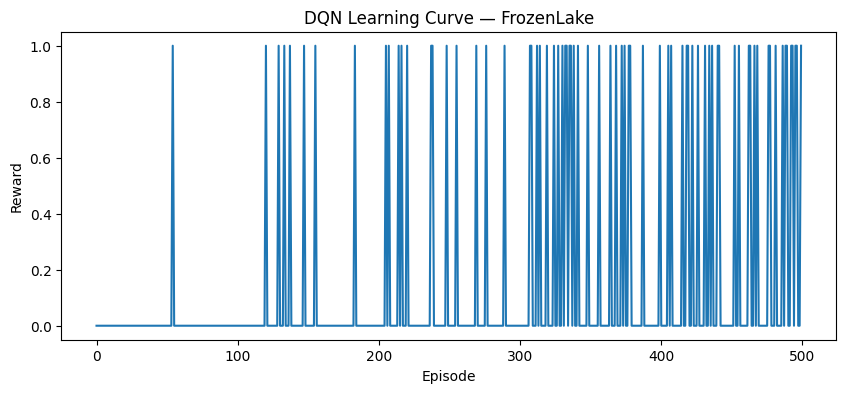

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rewards_frozenlake)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN Learning Curve — FrozenLake')
plt.show()

In [11]:
def train_dqn_v2(env_name, state_dim, action_dim, episodes=1000, discrete_state=False, n_states=None,
                   epsilon_decay=0.998, lr=0.001):
    env = gym.make(env_name)
    policy_net = DQN(state_dim, action_dim).to(device)
    target_net = DQN(state_dim, action_dim).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    buffer = ReplayBuffer()

    epsilon = 1.0
    epsilon_min = 0.01
    gamma = 0.99
    batch_size = 64
    episode_rewards = []

    def encode_state(s):
        if discrete_state:
            one_hot = np.zeros(n_states, dtype=np.float32)
            one_hot[s] = 1.0
            return one_hot
        return np.array(s, dtype=np.float32)

    for episode in range(episodes):
        state, _ = env.reset()
        state = encode_state(state)
        total_reward = 0
        done = False

        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = policy_net(state_t).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_enc = encode_state(next_state)
            buffer.push(state, action, reward, next_state_enc, done)
            state = next_state_enc
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards, next_states, dones = buffer.sample(batch_size)
                states = torch.FloatTensor(states).to(device)
                actions = torch.LongTensor(actions).to(device)
                rewards = torch.FloatTensor(rewards).to(device)
                next_states = torch.FloatTensor(next_states).to(device)
                dones = torch.FloatTensor(dones).to(device)

                q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(next_states).max(1)[0]
                    target_q = rewards + gamma * next_q * (1 - dones)
                loss = nn.functional.mse_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

        if episode % 50 == 0:
            target_net.load_state_dict(policy_net.state_dict())
            recent_success = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else np.mean(episode_rewards)
            print(f"Episode {episode}, Recent success rate: {recent_success*100:.1f}%, Epsilon: {epsilon:.3f}")

    return policy_net, episode_rewards

policy_net_frozenlake_v2, rewards_frozenlake_v2 = train_dqn_v2(
    'FrozenLake-v1', state_dim=16, action_dim=4,
    episodes=1000, discrete_state=True, n_states=16, epsilon_decay=0.998
)

Episode 0, Recent success rate: 0.0%, Epsilon: 0.998
Episode 50, Recent success rate: 4.0%, Epsilon: 0.903
Episode 100, Recent success rate: 4.0%, Epsilon: 0.817
Episode 150, Recent success rate: 2.0%, Epsilon: 0.739
Episode 200, Recent success rate: 2.0%, Epsilon: 0.669
Episode 250, Recent success rate: 2.0%, Epsilon: 0.605
Episode 300, Recent success rate: 2.0%, Epsilon: 0.547
Episode 350, Recent success rate: 2.0%, Epsilon: 0.495
Episode 400, Recent success rate: 2.0%, Epsilon: 0.448
Episode 450, Recent success rate: 8.0%, Epsilon: 0.405
Episode 500, Recent success rate: 6.0%, Epsilon: 0.367
Episode 550, Recent success rate: 2.0%, Epsilon: 0.332
Episode 600, Recent success rate: 10.0%, Epsilon: 0.300
Episode 650, Recent success rate: 10.0%, Epsilon: 0.272
Episode 700, Recent success rate: 14.0%, Epsilon: 0.246
Episode 750, Recent success rate: 16.0%, Epsilon: 0.222
Episode 800, Recent success rate: 22.0%, Epsilon: 0.201
Episode 850, Recent success rate: 18.0%, Epsilon: 0.182
Episode

In [12]:
success_rate_fl2, avg_reward_fl2 = evaluate_policy(policy_net_frozenlake_v2, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16)
print(f"FrozenLake v2 final policy — success rate: {success_rate_fl2*100:.1f}%")

FrozenLake v2 final policy — success rate: 71.0%


In [13]:
def continue_training(policy_net, target_net_state, env_name, episodes, discrete_state, n_states,
                        epsilon_start, epsilon_decay=0.999):
    env = gym.make(env_name)
    target_net = DQN(n_states, 4).to(device)
    target_net.load_state_dict(target_net_state)
    optimizer = optim.Adam(policy_net.parameters(), lr=0.0005)
    buffer = ReplayBuffer()
    epsilon = epsilon_start
    epsilon_min = 0.01
    gamma = 0.99
    batch_size = 64
    episode_rewards = []

    def encode_state(s):
        one_hot = np.zeros(n_states, dtype=np.float32)
        one_hot[s] = 1.0
        return one_hot

    for episode in range(episodes):
        state, _ = env.reset()
        state = encode_state(state)
        total_reward = 0
        done = False
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = policy_net(state_t).argmax().item()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_enc = encode_state(next_state)
            buffer.push(state, action, reward, next_state_enc, done)
            state = next_state_enc
            total_reward += reward
            if len(buffer) >= batch_size:
                states, actions, rewards, next_states, dones = buffer.sample(batch_size)
                states = torch.FloatTensor(states).to(device)
                actions = torch.LongTensor(actions).to(device)
                rewards = torch.FloatTensor(rewards).to(device)
                next_states = torch.FloatTensor(next_states).to(device)
                dones = torch.FloatTensor(dones).to(device)
                q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(next_states).max(1)[0]
                    target_q = rewards + gamma * next_q * (1 - dones)
                loss = nn.functional.mse_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        if episode % 50 == 0:
            target_net.load_state_dict(policy_net.state_dict())
            print(f"Episode {episode}, Recent success: {np.mean(episode_rewards[-50:])*100:.1f}%, Epsilon: {epsilon:.3f}")
    return policy_net, episode_rewards

policy_net_frozenlake_v3, rewards_fl3 = continue_training(
    policy_net_frozenlake_v2, policy_net_frozenlake_v2.state_dict(),
    'FrozenLake-v1', episodes=500, discrete_state=True, n_states=16, epsilon_start=0.15
)

Episode 0, Recent success: 0.0%, Epsilon: 0.150
Episode 50, Recent success: 20.0%, Epsilon: 0.143
Episode 100, Recent success: 26.0%, Epsilon: 0.136
Episode 150, Recent success: 26.0%, Epsilon: 0.129
Episode 200, Recent success: 24.0%, Epsilon: 0.123
Episode 250, Recent success: 26.0%, Epsilon: 0.117
Episode 300, Recent success: 40.0%, Epsilon: 0.111
Episode 350, Recent success: 30.0%, Epsilon: 0.106
Episode 400, Recent success: 36.0%, Epsilon: 0.100
Episode 450, Recent success: 40.0%, Epsilon: 0.096


In [14]:
success_rate_fl3, _ = evaluate_policy(policy_net_frozenlake_v3, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16)
print(f"FrozenLake v3 final policy — success rate: {success_rate_fl3*100:.1f}%")

FrozenLake v3 final policy — success rate: 77.0%


In [15]:
def tabular_q_learning(episodes=2000, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.999, epsilon_min=0.01):
    env = gym.make('FrozenLake-v1', is_slippery=False)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    epsilon = epsilon_start
    success_history = []

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) * (1 - done) - Q[state, action])
            state = next_state
            total_reward += reward
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        success_history.append(total_reward)
        if episode % 200 == 0:
            print(f"Episode {episode}, Recent success: {np.mean(success_history[-200:])*100:.1f}%, Epsilon: {epsilon:.3f}")

    return Q, success_history

Q_table, success_history = tabular_q_learning()

Episode 0, Recent success: 0.0%, Epsilon: 0.999
Episode 200, Recent success: 0.5%, Epsilon: 0.818
Episode 400, Recent success: 10.0%, Epsilon: 0.670
Episode 600, Recent success: 26.5%, Epsilon: 0.548
Episode 800, Recent success: 44.0%, Epsilon: 0.449
Episode 1000, Recent success: 53.0%, Epsilon: 0.367
Episode 1200, Recent success: 61.0%, Epsilon: 0.301
Episode 1400, Recent success: 68.0%, Epsilon: 0.246
Episode 1600, Recent success: 77.5%, Epsilon: 0.202
Episode 1800, Recent success: 84.0%, Epsilon: 0.165


In [16]:
def evaluate_tabular_policy(Q, episodes=100):
    env = gym.make('FrozenLake-v1', is_slippery=False)
    successes = 0
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        if reward > 0:
            successes += 1
    return successes / episodes

final_success_rate = evaluate_tabular_policy(Q_table, episodes=100)
print(f"Tabular Q-learning final policy — success rate: {final_success_rate*100:.1f}%")

Tabular Q-learning final policy — success rate: 100.0%


In [18]:
def train_double_dqn(env_name='FrozenLake-v1', is_slippery=False, episodes=1500, n_states=16, n_actions=4,
                       epsilon_decay=0.998, lr=0.001):
    env = gym.make(env_name, is_slippery=is_slippery)
    policy_net = DQN(n_states, n_actions).to(device)
    target_net = DQN(n_states, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    buffer = ReplayBuffer()

    epsilon = 1.0
    epsilon_min = 0.01
    gamma = 0.99
    batch_size = 64
    episode_rewards = []

    def encode_state(s):
        one_hot = np.zeros(n_states, dtype=np.float32)
        one_hot[s] = 1.0
        return one_hot

    for episode in range(episodes):
        state, _ = env.reset()
        state = encode_state(state)
        total_reward = 0
        done = False
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = policy_net(state_t).argmax().item()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_enc = encode_state(next_state)
            buffer.push(state, action, reward, next_state_enc, done)
            state = next_state_enc
            total_reward += reward

            if len(buffer) >= batch_size:
                states, actions, rewards, next_states, dones = buffer.sample(batch_size)
                states = torch.FloatTensor(states).to(device)
                actions = torch.LongTensor(actions).to(device)
                rewards = torch.FloatTensor(rewards).to(device)
                next_states = torch.FloatTensor(next_states).to(device)
                dones = torch.FloatTensor(dones).to(device)

                q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    # Double DQN: select action with online network, evaluate with target network
                    best_actions = policy_net(next_states).argmax(1)
                    next_q = target_net(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
                    target_q = rewards + gamma * next_q * (1 - dones)
                loss = nn.functional.mse_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        if episode % 100 == 0:
            target_net.load_state_dict(policy_net.state_dict())
            recent = np.mean(episode_rewards[-100:]) if len(episode_rewards)>=100 else np.mean(episode_rewards)
            print(f"Episode {episode}, Recent success: {recent*100:.1f}%, Epsilon: {epsilon:.3f}")

    return policy_net, episode_rewards

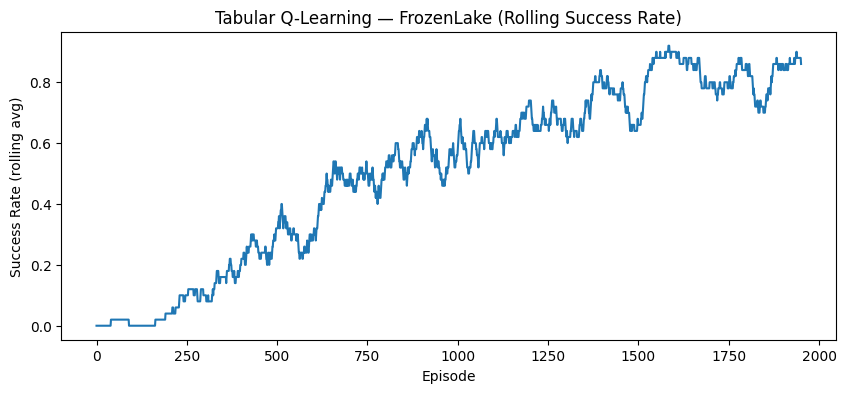

In [19]:
plt.figure(figsize=(10,4))
window = 50
smoothed = np.convolve(success_history, np.ones(window)/window, mode='valid')
plt.plot(smoothed)
plt.xlabel('Episode')
plt.ylabel('Success Rate (rolling avg)')
plt.title('Tabular Q-Learning — FrozenLake (Rolling Success Rate)')
plt.show()

In [20]:
policy_net_ddqn, rewards_ddqn = train_double_dqn(is_slippery=False, episodes=1500)

Episode 0, Recent success: 0.0%, Epsilon: 0.998
Episode 100, Recent success: 1.0%, Epsilon: 0.817
Episode 200, Recent success: 4.0%, Epsilon: 0.669
Episode 300, Recent success: 20.0%, Epsilon: 0.547
Episode 400, Recent success: 32.0%, Epsilon: 0.448
Episode 500, Recent success: 37.0%, Epsilon: 0.367
Episode 600, Recent success: 55.0%, Epsilon: 0.300
Episode 700, Recent success: 74.0%, Epsilon: 0.246
Episode 800, Recent success: 70.0%, Epsilon: 0.201
Episode 900, Recent success: 84.0%, Epsilon: 0.165
Episode 1000, Recent success: 81.0%, Epsilon: 0.135
Episode 1100, Recent success: 87.0%, Epsilon: 0.110
Episode 1200, Recent success: 94.0%, Epsilon: 0.090
Episode 1300, Recent success: 88.0%, Epsilon: 0.074
Episode 1400, Recent success: 93.0%, Epsilon: 0.061


In [21]:
success_rate_ddqn, _ = evaluate_policy(policy_net_ddqn, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16)
print(f"Double DQN final policy — success rate: {success_rate_ddqn*100:.1f}%")

Double DQN final policy — success rate: 4.0%


In [22]:
success_rate_ddqn, _ = evaluate_policy(policy_net_ddqn, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16)
print(f"Current eval: {success_rate_ddqn*100:.1f}%")

# Check the raw reward history for the last 100 episodes of training
print(f"Last 100 training episodes success rate: {np.mean(rewards_ddqn[-100:])*100:.1f}%")
print(f"Episodes 1300-1400 success rate: {np.mean(rewards_ddqn[1300:1400])*100:.1f}%")
print(f"Episodes 1400-1500 success rate: {np.mean(rewards_ddqn[1400:1500])*100:.1f}%")

Current eval: 5.0%
Last 100 training episodes success rate: 97.0%
Episodes 1300-1400 success rate: 93.0%
Episodes 1400-1500 success rate: 97.0%


In [23]:
def evaluate_policy_fixed(policy_net, env_name, episodes=100, discrete_state=False, n_states=None, is_slippery=False):
    env = gym.make(env_name, is_slippery=is_slippery) if 'FrozenLake' in env_name else gym.make(env_name)
    successes = 0
    total_rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        if discrete_state:
            state_enc = np.zeros(n_states, dtype=np.float32)
            state_enc[state] = 1.0
        else:
            state_enc = np.array(state, dtype=np.float32)
        done = False
        ep_reward = 0
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state_enc).unsqueeze(0).to(device)
                action = policy_net(state_t).argmax().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            if discrete_state:
                state_enc = np.zeros(n_states, dtype=np.float32)
                state_enc[state] = 1.0
            else:
                state_enc = np.array(state, dtype=np.float32)
        total_rewards.append(ep_reward)
        if ep_reward > 0:
            successes += 1
    return successes / episodes, np.mean(total_rewards)

success_rate_ddqn_fixed, _ = evaluate_policy_fixed(policy_net_ddqn, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16, is_slippery=False)
print(f"Double DQN (correctly evaluated, deterministic) — success rate: {success_rate_ddqn_fixed*100:.1f}%")

Double DQN (correctly evaluated, deterministic) — success rate: 100.0%


In [24]:
env_debug = gym.make('FrozenLake-v1', is_slippery=False)
state, _ = env_debug.reset()
print(f"Initial state: {state}")

for step in range(10):
    state_enc = np.zeros(16, dtype=np.float32)
    state_enc[state] = 1.0
    with torch.no_grad():
        state_t = torch.FloatTensor(state_enc).unsqueeze(0).to(device)
        q_vals = policy_net_ddqn(state_t)
        action = q_vals.argmax().item()
    print(f"Step {step}: state={state}, Q-values={q_vals.cpu().numpy()}, action={action}")
    state, reward, terminated, truncated, _ = env_debug.step(action)
    print(f"  -> next_state={state}, reward={reward}, done={terminated or truncated}")
    if terminated or truncated:
        break

Initial state: 0
Step 0: state=0, Q-values=[[0.930776   0.935748   0.93141294 0.9310636 ]], action=1
  -> next_state=4, reward=0.0, done=False
Step 1: state=4, Q-values=[[ 9.3579382e-01  9.3678451e-01 -3.4676492e-04  9.3100709e-01]], action=1
  -> next_state=8, reward=0.0, done=False
Step 2: state=8, Q-values=[[ 9.3736088e-01 -1.9678473e-04  9.5948482e-01  9.3666738e-01]], action=2
  -> next_state=9, reward=0.0, done=False
Step 3: state=9, Q-values=[[9.3725193e-01 9.8051310e-01 9.7961581e-01 8.4251165e-04]], action=1
  -> next_state=13, reward=0.0, done=False
Step 4: state=13, Q-values=[[0.00212376 0.98051155 0.98957145 0.9584052 ]], action=2
  -> next_state=14, reward=0.0, done=False
Step 5: state=14, Q-values=[[0.9805799  0.99005497 0.9986796  0.9811051 ]], action=2
  -> next_state=15, reward=1.0, done=True


In [25]:
def evaluate_policy_fixed(policy_net, env_name, episodes=100, discrete_state=False, n_states=None, is_slippery=False):
    env = gym.make(env_name, is_slippery=is_slippery) if 'FrozenLake' in env_name else gym.make(env_name)
    successes = 0
    for _ in range(episodes):
        state, _ = env.reset()
        if discrete_state:
            state_enc = np.zeros(n_states, dtype=np.float32)
            state_enc[state] = 1.0
        else:
            state_enc = np.array(state, dtype=np.float32)
        done = False
        ep_reward = 0
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state_enc).unsqueeze(0).to(device)
                action = policy_net(state_t).argmax().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            if discrete_state:
                state_enc = np.zeros(n_states, dtype=np.float32)
                state_enc[state] = 1.0
            else:
                state_enc = np.array(state, dtype=np.float32)
        if ep_reward > 0:
            successes += 1
    return successes / episodes, None

success_dqn_fixed, _ = evaluate_policy_fixed(policy_net_frozenlake, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16, is_slippery=False)
success_v2_fixed, _ = evaluate_policy_fixed(policy_net_frozenlake_v2, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16, is_slippery=False)
success_v3_fixed, _ = evaluate_policy_fixed(policy_net_frozenlake_v3, 'FrozenLake-v1', episodes=100, discrete_state=True, n_states=16, is_slippery=False)

print(f"DQN (basic, corrected eval): {success_dqn_fixed*100:.1f}%")
print(f"DQN-v2 (extended, corrected eval): {success_v2_fixed*100:.1f}%")
print(f"DQN-v3 (further trained, corrected eval): {success_v3_fixed*100:.1f}%")

DQN (basic, corrected eval): 0.0%
DQN-v2 (extended, corrected eval): 0.0%
DQN-v3 (further trained, corrected eval): 0.0%


In [26]:
print(type(success_dqn_fixed), success_dqn_fixed)
print(type(success_v2_fixed), success_v2_fixed)
print(type(success_v3_fixed), success_v3_fixed)

<class 'float'> 0.0
<class 'float'> 0.0
<class 'float'> 0.0


In [27]:
env_check = gym.make('FrozenLake-v1', is_slippery=False)
state, _ = env_check.reset()
print(f"Initial state: {state}")
for step in range(10):
    state_enc = np.zeros(16, dtype=np.float32)
    state_enc[state] = 1.0
    with torch.no_grad():
        state_t = torch.FloatTensor(state_enc).unsqueeze(0).to(device)
        action = policy_net_frozenlake.argmax(1).item() if False else policy_net_frozenlake(state_t).argmax().item()
    state, reward, terminated, truncated, _ = env_check.step(action)
    print(f"Step {step}: action={action}, next_state={state}, reward={reward}, done={terminated or truncated}")
    if terminated or truncated:
        break

Initial state: 0
Step 0: action=0, next_state=0, reward=0.0, done=False
Step 1: action=0, next_state=0, reward=0.0, done=False
Step 2: action=0, next_state=0, reward=0.0, done=False
Step 3: action=0, next_state=0, reward=0.0, done=False
Step 4: action=0, next_state=0, reward=0.0, done=False
Step 5: action=0, next_state=0, reward=0.0, done=False
Step 6: action=0, next_state=0, reward=0.0, done=False
Step 7: action=0, next_state=0, reward=0.0, done=False
Step 8: action=0, next_state=0, reward=0.0, done=False
Step 9: action=0, next_state=0, reward=0.0, done=False
